In [2]:
using Dates
using DifferentialEquations
using LinearAlgebra
using Random


timestamp = Dates.now()
seed = Int(floor(Dates.datetime2unix(timestamp)))
Random.seed!(seed)

TaskLocalRNG()

In [ ]:
function heisenberg_chain!(dS, S, p, t)
    N, J = p

    S_mat = reshape(S, (3, N))
    dS_mat = reshape(dS, (3, N))

    # Periodic boundary conditions
    for i in 1:N
        ip1 = mod1(i+1, N)
        im1 = mod1(i-1, N)
        local_field = J * (S_mat[:, im1] + S_mat[:, ip1])
        dS_mat[:, i] .= cross(S_mat[:, i], local_field) ## Ferromagnetic coupling
    end
end

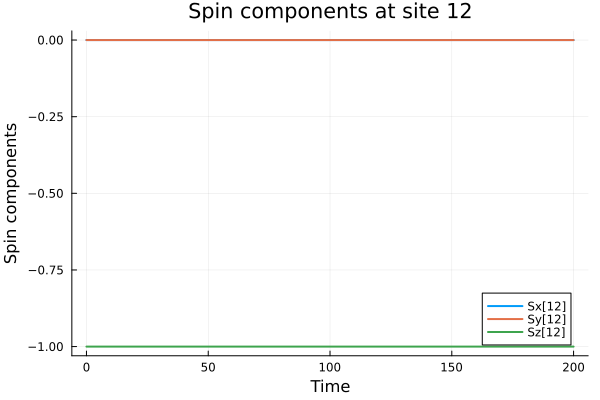

In [8]:
using DifferentialEquations
using LinearAlgebra
using Random
using Plots
using StaticArrays


timestamp = Dates.now()
seed = Int(floor(Dates.datetime2unix(timestamp)))
Random.seed!(seed)

# ----------------------------
# Parameters
# ----------------------------       # reproducible
L = 100                  # chain length (L = number of sites)
J = 1.0                  # |J_x| = |J_y| = J_z = J
Jz = J
Δ = 0.5                  # discrete time step for sign flips (tau units)
Tfinal = 200.0           # final time (tau)
nsteps = Int(ceil(Tfinal / Δ))   # number of sign-steps
tspan = (0.0, Tfinal)

#Jx_steps = [rand() < 0.5 ? -1 : 1 for _ in 1:nsteps]
#Jy_steps = [rand() < 0.5 ? -1 : 1 for _ in 1:nsteps]

Jx_steps = [1.0 for _ in 1:nsteps]  # for testing: 1
Jy_steps = [1.0 for _ in 1:nsteps]   # for testing: 1

# zero-order-hold helper: give Jx(t), Jy(t) for any time t
# clamp index to [1, nsteps]
function sign_at_time(t, steps, Δ)
    idx = clamp(floor(Int, t / Δ) + 1, 1, length(steps))
    return steps[idx]
end

# ----------------------------
# Equations of motion
# ----------------------------
# state vector S is length 3L, arranged as columns: [S[:,1]; S[:,2]; ...] = vec(S_matrix)
function heisenberg_stochastic!(dS, Svec, p, t)
    L, Jz, Jx_steps, Jy_steps, Δ = p
    # reshape into 3 x L
    S = reshape(Svec, (3, L))
    dS_mat = reshape(dS, (3, L))

    # current signs
    Jx_sign = sign_at_time(t, Jx_steps, Δ)
    Jy_sign = sign_at_time(t, Jy_steps, Δ)

    # loop through sites with periodic bc
    for j in 1:L
        jm = j == 1 ? L : j - 1
        jp = j == L ? 1 : j + 1

        # tilde S for neighbors (weighted by current Jx(t), Jy(t), fixed Jz)
        tilde_m = @SVector [ Jx_sign * S[1, jm], Jy_sign * S[2, jm], Jz * S[3, jm] ]
        tilde_p = @SVector [ Jx_sign * S[1, jp], Jy_sign * S[2, jp], Jz * S[3, jp] ]

        local_field = tilde_m + tilde_p

        # cross product local_field × S_j with minus sign: dS_j = - local_field × S_j
        # (the formula in the prompt has dS_j/dτ = - (tilde_{j-1}+tilde_{j+1}) × S_j )
        Sj = S[:, j]
        dS_mat[:, j] .= -cross(local_field, Sj)
    end
end

# ----------------------------
# Initial condition (example: random normalized spins)
# ----------------------------
#S0 = randn(3, L)

"""
N = L
S0 = zeros(3, N)
for i in 1:N
    if isodd(i)
        S0[:, i] = [0.0, 0.0, 1.0]   
    else
        S0[:, i] = [0.0, 0.0, -1.0]  
    end
end


for j in 1:L
    S0[:, j] ./= norm(S0[:, j])
end
S0_vec = vec(S0)
"""

ϕ = 2*π/4
function angle_v(i)
    [0.0, cos(i * ϕ), sin(i * ϕ)]
end

S0 = zeros(3, N)
for i in 1:N
    S0[:, i] = angle_v(i)
end

# pack parameters for the ODE function
p = (L, Jz, Jx_steps, Jy_steps, Δ)

# ----------------------------
# Solve
# ----------------------------
prob = ODEProblem(heisenberg_stochastic!, S0_vec, tspan, p)

# Choose solver and tolerances; saveat for output sampling
save_dt = 0.1
sol = solve(prob, Tsit5(), reltol=1e-7, abstol=1e-9, saveat=save_dt)

# ----------------------------
# Diagnostics & plotting
# ----------------------------
# pick a site to inspect
site = 12
S_site_t = [reshape(u, (3, L))[:, site] for u in sol.u]
Sx = [s[1] for s in S_site_t]
Sy = [s[2] for s in S_site_t]
Sz = [s[3] for s in S_site_t]

t = sol.t
plt1 = plot(t, Sx, label="Sx[$site]", lw=2)
plot!(t, Sy, label="Sy[$site]", lw=2)
plot!(t, Sz, label="Sz[$site]", lw=2)
xlabel!("Time")
ylabel!("Spin components")
title!("Spin components at site $site")

# display
plot(plt1)   # spin components plot

In [5]:
ϕ = 2*π/4
function angle_v(i)
    [cos(i * ϕ), sin(i * ϕ), 0.0]
end

S0 = zeros(3, N)
for i in 1:N
    S0[:, i] = angle_v(i)
end

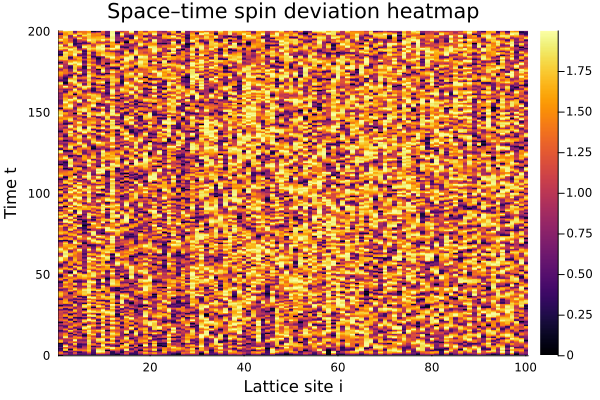

In [15]:
using DifferentialEquations
using LinearAlgebra
using Random
using Plots
using StaticArrays
using Dates

gr(fmt = :png)

# --------------------------------------------------
# Random seed (reproducible but time-based)
# --------------------------------------------------
timestamp = Dates.now()
seed = Int(floor(Dates.datetime2unix(timestamp)))
Random.seed!(seed)

# --------------------------------------------------
# Parameters
# --------------------------------------------------
L = 100                     # chain length
J = 1.0
Jz = J
Δ = 0.5                     # sign-flip interval
Tfinal = 200.0
tspan = (0.0, Tfinal)
nsteps = Int(ceil(Tfinal / Δ))

# Random ±1 couplings
#Jx_steps = [rand() < 0.5 ? -1.0 : 1.0 for _ in 1:nsteps]
#Jy_steps = [rand() < 0.5 ? -1.0 : 1.0 for _ in 1:nsteps]

Jx_steps = [1.0 for _ in 1:nsteps]  # for testing: 1
Jy_steps = [1.0 for _ in 1:nsteps]   # for testing: 1

# --------------------------------------------------
# Zero-order-hold coupling lookup
# --------------------------------------------------
function sign_at_time(t, steps, Δ)
    idx = clamp(floor(Int, t / Δ) + 1, 1, length(steps))
    return steps[idx]
end

# --------------------------------------------------
# Equations of motion
# --------------------------------------------------
function heisenberg_stochastic!(dS, Svec, p, t)
    L, Jz, Jx_steps, Jy_steps, Δ = p
    S = reshape(Svec, (3, L))
    dS_mat = reshape(dS, (3, L))

    Jx = sign_at_time(t, Jx_steps, Δ)
    Jy = sign_at_time(t, Jy_steps, Δ)

    for j in 1:L
        jm = j == 1 ? L : j - 1
        jp = j == L ? 1 : j + 1

        tilde_m = @SVector [Jx * S[1, jm], Jy * S[2, jm], Jz * S[3, jm]]
        tilde_p = @SVector [Jx * S[1, jp], Jy * S[2, jp], Jz * S[3, jp]]

        local_field = tilde_m + tilde_p
        dS_mat[:, j] .= -cross(local_field, S[:, j])
    end
end

# --------------------------------------------------
# Initial condition: spiral state
# S_j = (0, cos(πj/2), sin(πj/2))
# --------------------------------------------------
"""
ϕ = π / 2
S0 = zeros(3, L)
for j in 1:L
    S0[:, j] = [0.0, cos(j * ϕ), sin(j * ϕ)]
end
"""

S0 = randn(3, N)
for i in 1:N
    S0[:, i] ./= norm(S0[:, i])
end

S0_vec = vec(S0)

# --------------------------------------------------
# Solve ODE
# --------------------------------------------------
p = (L, Jz, Jx_steps, Jy_steps, Δ)
save_dt = 0.5

prob = ODEProblem(heisenberg_stochastic!, S0_vec, tspan, p)
sol = solve(prob, Tsit5(),
            reltol = 1e-7,
            abstol = 1e-9,
            saveat = save_dt)

# --------------------------------------------------
# Space–time heatmap: ‖S_i(t) − S_i(0)‖
# --------------------------------------------------
nt = length(sol.t)
dist_map = zeros(nt, L)

S0_mat = reshape(S0_vec, (3, L))

for (ti, u) in enumerate(sol.u)
    S_mat = reshape(u, (3, L))
    for i in 1:L
        dist_map[ti, i] = norm(S_mat[:, i] - S0_mat[:, i])
    end
end

# --------------------------------------------------
# Plot heatmap
# --------------------------------------------------
plt = heatmap(
    1:L, sol.t, dist_map,
    xlabel = "Lattice site i",
    ylabel = "Time t",
    #colorbar_title = "‖Sᵢ(t) − Sᵢ(0)‖",
    title = "Space–time spin deviation heatmap",
    aspect_ratio = :auto
)

display(plt)


In [ ]:
function projector_θ_full(S)
    ϕ = π / 2
    
    S0 = zeros(3, L)
    
    for j in 1:L
        S0[:, j] = [0.0, cos(j * ϕ), sin(j * ϕ)]
    end
    
    θ_proj = copy(S0)

    return θ_proj
end


function control_map(S_initial, S_target, N, J, p_ctrl;
                     T = 100.0, dt = 0.1, max_steps = 100)

    tspan = (0.0, T)
    p = (N, J)
    S0_vec = vec(S_initial)

    F_list = Float64[]
    D_list = Float64[]

    for step in 1:max_steps
        prob = ODEProblem(heisenberg_chain!, S0_vec, tspan, p)
        sol = solve(prob, Tsit5(), reltol = 1e-6, abstol = 1e-6, saveat = dt)
        S_final = reshape(sol.u[end], (3, N))

        
        #F = fidelity(S_final, S_target)
        D = norm(vec(S_final) - vec(S_target))

        #push!(F_list, F)
        push!(D_list, D)

        println("Step $step — Fidelity = $(round(F, digits = 6)), Distance = $(round(D, digits = 6))")

       
        if D > 1 - 1e-8
            break
        end

        
        if rand() < p_ctrl
            S_final = projector_θ(S_final, p_ctrl)
        end

        S0_vec = vec(S_final)
    end
end

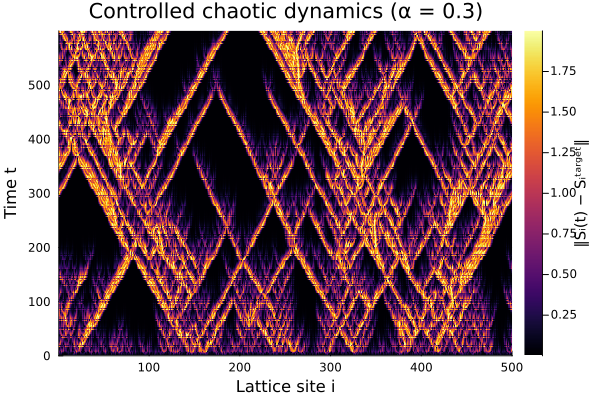

In [18]:
using DifferentialEquations
using LinearAlgebra
using Random
using Plots
using StaticArrays
using Dates
using Statistics

gr(fmt = :png)

# --------------------------------------------------
# Random seed
# --------------------------------------------------
Random.seed!(1234)

# --------------------------------------------------
# Parameters
# --------------------------------------------------
L = 500                     # chain length
J = 1.0
Jz = J
Δ = 0.5                     # coupling sign flip interval
Tcontrol = 1.0              # time between measurements
Ncontrol = 500              # number of control steps
save_dt = 0.2

α = 0.3                     # <<< CONTROL STRENGTH (CHANGE THIS)
threshold = 0.6             # instability threshold

# --------------------------------------------------
# Random ±Jx, ±Jy steps
# --------------------------------------------------
Tfinal = Ncontrol * Tcontrol
nsteps = Int(ceil(Tfinal / Δ))

#Jx_steps = [rand() < 0.5 ? -1.0 : 1.0 for _ in 1:nsteps]
#Jy_steps = [rand() < 0.5 ? -1.0 : 1.0 for _ in 1:nsteps]

Jx_steps = [1.0 for _ in 1:nsteps]  # for testing: 1
Jy_steps = [1.0 for _ in 1:nsteps]   # for testing: 1

# --------------------------------------------------
# Helper: zero-order-hold
# --------------------------------------------------
function sign_at_time(t, steps, Δ)
    idx = clamp(floor(Int, t / Δ) + 1, 1, length(steps))
    return steps[idx]
end

# --------------------------------------------------
# Equations of motion
# --------------------------------------------------
function heisenberg_stochastic!(dS, Svec, p, t)
    L, Jz, Jx_steps, Jy_steps, Δ = p
    S = reshape(Svec, (3, L))
    dS_mat = reshape(dS, (3, L))

    Jx = sign_at_time(t, Jx_steps, Δ)
    Jy = sign_at_time(t, Jy_steps, Δ)

    for j in 1:L
        jm = j == 1 ? L : j - 1
        jp = j == L ? 1 : j + 1

        tilde_m = @SVector [Jx * S[1, jm], Jy * S[2, jm], Jz * S[3, jm]]
        tilde_p = @SVector [Jx * S[1, jp], Jy * S[2, jp], Jz * S[3, jp]]

        dS_mat[:, j] .= -cross(tilde_m + tilde_p, S[:, j])
    end
end

# --------------------------------------------------
# Spiral fixed point (unstable)
# --------------------------------------------------
function spiral_state(L)
    ϕ = π / 2
    S = zeros(3, L)
    for j in 1:L
        S[:, j] = [0.0, cos(j * ϕ), sin(j * ϕ)]
    end
    return S
end

# --------------------------------------------------
# Control kick
# --------------------------------------------------
function control_kick!(S, Sspiral, α)
    for j in 1:size(S, 2)
        S[:, j] .= (1 - α) .* S[:, j] .+ α .* Sspiral[:, j]
        S[:, j] ./= norm(S[:, j])
    end
end

# --------------------------------------------------
# Initial condition (small perturbation of spiral)
# --------------------------------------------------
S_spiral = spiral_state(L)
S_current = copy(S_spiral)

for j in 1:L
    S_current[:, j] .+= 0.05 * randn(3)
    S_current[:, j] ./= norm(S_current[:, j])
end

# --------------------------------------------------
# Parameters pack
# --------------------------------------------------
p = (L, Jz, Jx_steps, Jy_steps, Δ)

# --------------------------------------------------
# STORAGE FOR HEATMAP
# --------------------------------------------------
times = Float64[]
states = Vector{Matrix{Float64}}()

# --------------------------------------------------
# CONTROL LOOP
# --------------------------------------------------
t_global = 0.0

for step in 1:Ncontrol
    prob = ODEProblem(
        heisenberg_stochastic!,
        vec(S_current),
        (0.0, Tcontrol),
        p
    )

    sol = solve(prob, Tsit5(),
                reltol = 1e-7,
                abstol = 1e-9,
                saveat = save_dt)

    for u in sol.u
        push!(states, reshape(u, (3, L)))
        push!(times, t_global)
        t_global += save_dt
    end

    # measurement
    d = mean(norm(states[end][:, j] - S_spiral[:, j]) for j in 1:L)

    # control
    if d > threshold
        control_kick!(S_current, S_spiral, α)
    else
        S_current .= states[end]
    end
end

# --------------------------------------------------
# BUILD HEATMAP DATA
# --------------------------------------------------
nt = length(times)
dist_map = zeros(nt, L)

for ti in 1:nt
    for j in 1:L
        dist_map[ti, j] = norm(states[ti][:, j] - S_spiral[:, j])
    end
end

# --------------------------------------------------
# PLOT HEATMAP
# --------------------------------------------------
plt = heatmap(
    1:L,
    times,
    dist_map,
    xlabel = "Lattice site i",
    ylabel = "Time t",
    colorbar_title = "‖Sᵢ(t) − Sᵢᵗᵃʳᵍᵉᵗ‖",
    title = "Controlled chaotic dynamics (α = $α)",
    aspect_ratio = :auto
)

display(plt)


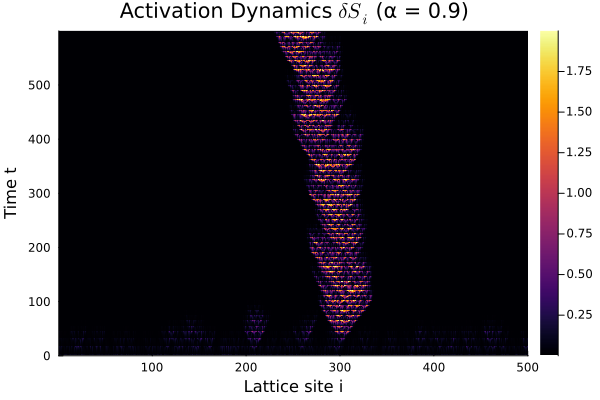

"/Users/dirac/Documents/spin-chain-control/actdynamics_0.9.svg"

In [38]:
using DifferentialEquations
using LinearAlgebra
using Random
using Plots
using StaticArrays
using Dates
using Statistics

gr(fmt = :png)

# --------------------------------------------------
# Random seed
# --------------------------------------------------
Random.seed!(1234)

# --------------------------------------------------
# Parameters
# --------------------------------------------------
L = 500                     # chain length
J = 1.0
Jz = J
Δ = 0.5                     # coupling sign flip interval
Tcontrol = 1.0              # time between measurements
Ncontrol = 500              # number of control steps
save_dt = 0.2

α = 0.9                   # <<< CONTROL STRENGTH (CHANGE THIS)
threshold = 0.1        # instability threshold

# --------------------------------------------------
# Random ±Jx, ±Jy steps
# --------------------------------------------------
Tfinal = Ncontrol * Tcontrol
nsteps = Int(ceil(Tfinal / Δ))

#Jx_steps = [rand() < 0.5 ? -1.0 : 1.0 for _ in 1:nsteps]
#Jy_steps = [rand() < 0.5 ? -1.0 : 1.0 for _ in 1:nsteps]

Jx_steps = [1.0 for _ in 1:nsteps]  # for testing: 1
Jy_steps = [1.0 for _ in 1:nsteps]   # for testing: 1

# --------------------------------------------------
# Helper: zero-order-hold
# --------------------------------------------------
function sign_at_time(t, steps, Δ)
    idx = clamp(floor(Int, t / Δ) + 1, 1, length(steps))
    return steps[idx]
end

# --------------------------------------------------
# Equations of motion
# --------------------------------------------------
function heisenberg_stochastic!(dS, Svec, p, t)
    L, Jz, Jx_steps, Jy_steps, Δ = p
    S = reshape(Svec, (3, L))
    dS_mat = reshape(dS, (3, L))

    Jx = sign_at_time(t, Jx_steps, Δ)
    Jy = sign_at_time(t, Jy_steps, Δ)

    for j in 1:L
        jm = j == 1 ? L : j - 1
        jp = j == L ? 1 : j + 1

        tilde_m = @SVector [Jx * S[1, jm], Jy * S[2, jm], Jz * S[3, jm]]
        tilde_p = @SVector [Jx * S[1, jp], Jy * S[2, jp], Jz * S[3, jp]]

        dS_mat[:, j] .= -cross(tilde_m + tilde_p, S[:, j])
    end
end

# --------------------------------------------------
# Spiral fixed point (unstable)
# --------------------------------------------------
function spiral_state(L)
    ϕ = π / 2
    S = zeros(3, L)
    for j in 1:L
        S[:, j] = [0.0, cos(j * ϕ), sin(j * ϕ)]
    end
    return S
end

# --------------------------------------------------
# Control kick
# --------------------------------------------------
function control_kick!(S, Sspiral, α)
    for j in 1:size(S, 2)
        S[:, j] .= (1 - α) .* S[:, j] .+ α .* Sspiral[:, j]
        S[:, j] ./= norm(S[:, j])
    end
end

# --------------------------------------------------
# Initial condition (small perturbation of spiral)
# --------------------------------------------------
S_spiral = spiral_state(L)
S_current = copy(S_spiral)

for j in 1:L
    S_current[:, j] .+= 0.5 * randn(3)
    S_current[:, j] ./= norm(S_current[:, j])
end

# --------------------------------------------------
# Parameters pack
# --------------------------------------------------
p = (L, Jz, Jx_steps, Jy_steps, Δ)

# --------------------------------------------------
# STORAGE FOR HEATMAP
# --------------------------------------------------
times = Float64[]
states = Vector{Matrix{Float64}}()

# --------------------------------------------------
# CONTROL LOOP
# --------------------------------------------------
t_global = 0.0

for step in 1:Ncontrol
    prob = ODEProblem(
        heisenberg_stochastic!,
        vec(S_current),
        (0.0, Tcontrol),
        p
    )

    sol = solve(prob, Tsit5(),
                reltol = 1e-7,
                abstol = 1e-9,
                saveat = save_dt)

    for u in sol.u
        push!(states, reshape(u, (3, L)))
        push!(times, t_global)
        t_global += save_dt
    end

    # measurement
    d = mean(norm(states[end][:, j] - S_spiral[:, j]) for j in 1:L)

    # control
    if d > threshold
        control_kick!(S_current, S_spiral, α)
    else
        S_current .= states[end]
    end
end

# --------------------------------------------------
# BUILD HEATMAP DATA
# --------------------------------------------------
nt = length(times)
dist_map = zeros(nt, L)

for ti in 1:nt
    for j in 1:L
        dist_map[ti, j] = norm(states[ti][:, j] - S_spiral[:, j])
    end
end

# --------------------------------------------------
# PLOT HEATMAP
# --------------------------------------------------
plt = heatmap(
    1:L,
    times,
    dist_map,
    xlabel = "Lattice site i",
    ylabel = "Time t",
    title = L"Activation Dynamics $\delta S_i$ (α = %$α)",
    aspect_ratio = :auto
)

display(plt)
savefig("actdynamics_$(α).svg")

In [35]:
using LaTeXStrings

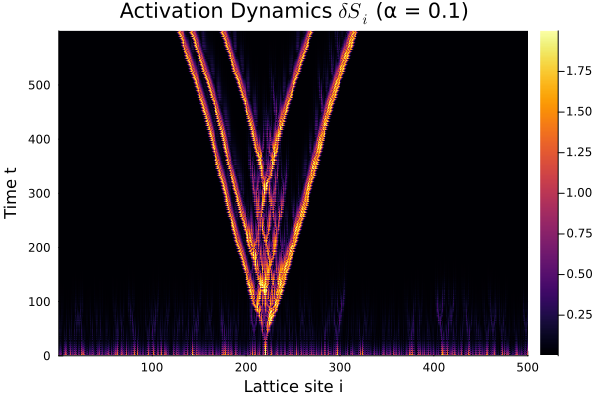

"/Users/dirac/Documents/spin-chain-control/actdynamics_0.1.svg"

In [39]:
using DifferentialEquations
using LinearAlgebra
using Random
using Plots
using StaticArrays
using Dates
using Statistics

gr(fmt = :png)

# --------------------------------------------------
# Random seed
# --------------------------------------------------
Random.seed!(1234)

# --------------------------------------------------
# Parameters
# --------------------------------------------------
L = 500                     # chain length
J = 1.0
Jz = J
Δ = 0.5                     # coupling sign flip interval
Tcontrol = 1.0              # time between measurements
Ncontrol = 500              # number of control steps
save_dt = 0.2

α = 0.1                   # <<< CONTROL STRENGTH (CHANGE THIS)
threshold = 0.1        # instability threshold

# --------------------------------------------------
# Random ±Jx, ±Jy steps
# --------------------------------------------------
Tfinal = Ncontrol * Tcontrol
nsteps = Int(ceil(Tfinal / Δ))

#Jx_steps = [rand() < 0.5 ? -1.0 : 1.0 for _ in 1:nsteps]
#Jy_steps = [rand() < 0.5 ? -1.0 : 1.0 for _ in 1:nsteps]

Jx_steps = [1.0 for _ in 1:nsteps]  # for testing: 1
Jy_steps = [1.0 for _ in 1:nsteps]   # for testing: 1

# --------------------------------------------------
# Helper: zero-order-hold
# --------------------------------------------------
function sign_at_time(t, steps, Δ)
    idx = clamp(floor(Int, t / Δ) + 1, 1, length(steps))
    return steps[idx]
end

# --------------------------------------------------
# Equations of motion
# --------------------------------------------------
function heisenberg_stochastic!(dS, Svec, p, t)
    L, Jz, Jx_steps, Jy_steps, Δ = p
    S = reshape(Svec, (3, L))
    dS_mat = reshape(dS, (3, L))

    Jx = sign_at_time(t, Jx_steps, Δ)
    Jy = sign_at_time(t, Jy_steps, Δ)

    for j in 1:L
        jm = j == 1 ? L : j - 1
        jp = j == L ? 1 : j + 1

        tilde_m = @SVector [Jx * S[1, jm], Jy * S[2, jm], Jz * S[3, jm]]
        tilde_p = @SVector [Jx * S[1, jp], Jy * S[2, jp], Jz * S[3, jp]]

        dS_mat[:, j] .= -cross(tilde_m + tilde_p, S[:, j])
    end
end

# --------------------------------------------------
# Spiral fixed point (unstable)
# --------------------------------------------------
function spiral_state(L)
    ϕ = π / 2
    S = zeros(3, L)
    for j in 1:L
        S[:, j] = [0.0, cos(j * ϕ), sin(j * ϕ)]
    end
    return S
end

# --------------------------------------------------
# Control kick
# --------------------------------------------------
function control_kick!(S, Sspiral, α)
    for j in 1:size(S, 2)
        S[:, j] .= (1 - α) .* S[:, j] .+ α .* Sspiral[:, j]
        S[:, j] ./= norm(S[:, j])
    end
end

# --------------------------------------------------
# Initial condition (small perturbation of spiral)
# --------------------------------------------------
S_spiral = spiral_state(L)
S_current = copy(S_spiral)

for j in 1:L
    S_current[:, j] .+= 0.5 * randn(3)
    S_current[:, j] ./= norm(S_current[:, j])
end

# --------------------------------------------------
# Parameters pack
# --------------------------------------------------
p = (L, Jz, Jx_steps, Jy_steps, Δ)

# --------------------------------------------------
# STORAGE FOR HEATMAP
# --------------------------------------------------
times = Float64[]
states = Vector{Matrix{Float64}}()

# --------------------------------------------------
# CONTROL LOOP
# --------------------------------------------------
t_global = 0.0

for step in 1:Ncontrol
    prob = ODEProblem(
        heisenberg_stochastic!,
        vec(S_current),
        (0.0, Tcontrol),
        p
    )

    sol = solve(prob, Tsit5(),
                reltol = 1e-7,
                abstol = 1e-9,
                saveat = save_dt)

    for u in sol.u
        push!(states, reshape(u, (3, L)))
        push!(times, t_global)
        t_global += save_dt
    end

    # measurement
    d = mean(norm(states[end][:, j] - S_spiral[:, j]) for j in 1:L)

    # control
    if d > threshold
        control_kick!(S_current, S_spiral, α)
    else
        S_current .= states[end]
    end
end

# --------------------------------------------------
# BUILD HEATMAP DATA
# --------------------------------------------------
nt = length(times)
dist_map = zeros(nt, L)

for ti in 1:nt
    for j in 1:L
        dist_map[ti, j] = norm(states[ti][:, j] - S_spiral[:, j])
    end
end

# --------------------------------------------------
# PLOT HEATMAP
# --------------------------------------------------
plt = heatmap(
    1:L,
    times,
    dist_map,
    xlabel = "Lattice site i",
    ylabel = "Time t",
    title = L"Activation Dynamics $\delta S_i$ (α = %$α)",
    aspect_ratio = :auto
)

display(plt)
savefig("actdynamics_$(α).svg")

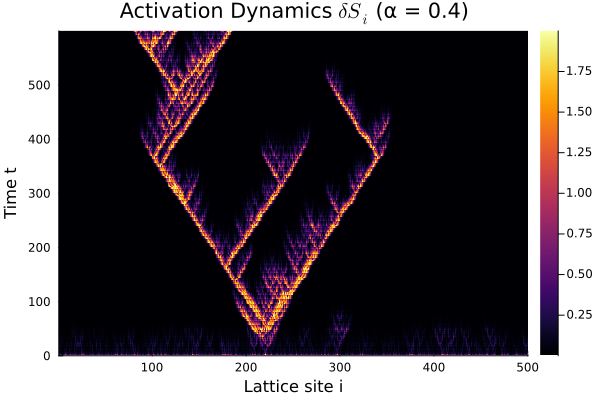

"/Users/dirac/Documents/spin-chain-control/actdynamics_0.4.svg"

In [40]:
using DifferentialEquations
using LinearAlgebra
using Random
using Plots
using StaticArrays
using Dates
using Statistics

gr(fmt = :png)

# --------------------------------------------------
# Random seed
# --------------------------------------------------
Random.seed!(1234)

# --------------------------------------------------
# Parameters
# --------------------------------------------------
L = 500                     # chain length
J = 1.0
Jz = J
Δ = 0.5                     # coupling sign flip interval
Tcontrol = 1.0              # time between measurements
Ncontrol = 500              # number of control steps
save_dt = 0.2

α = 0.4                   # <<< CONTROL STRENGTH (CHANGE THIS)
threshold = 0.1        # instability threshold

# --------------------------------------------------
# Random ±Jx, ±Jy steps
# --------------------------------------------------
Tfinal = Ncontrol * Tcontrol
nsteps = Int(ceil(Tfinal / Δ))

#Jx_steps = [rand() < 0.5 ? -1.0 : 1.0 for _ in 1:nsteps]
#Jy_steps = [rand() < 0.5 ? -1.0 : 1.0 for _ in 1:nsteps]

Jx_steps = [1.0 for _ in 1:nsteps]  # for testing: 1
Jy_steps = [1.0 for _ in 1:nsteps]   # for testing: 1

# --------------------------------------------------
# Helper: zero-order-hold
# --------------------------------------------------
function sign_at_time(t, steps, Δ)
    idx = clamp(floor(Int, t / Δ) + 1, 1, length(steps))
    return steps[idx]
end

# --------------------------------------------------
# Equations of motion
# --------------------------------------------------
function heisenberg_stochastic!(dS, Svec, p, t)
    L, Jz, Jx_steps, Jy_steps, Δ = p
    S = reshape(Svec, (3, L))
    dS_mat = reshape(dS, (3, L))

    Jx = sign_at_time(t, Jx_steps, Δ)
    Jy = sign_at_time(t, Jy_steps, Δ)

    for j in 1:L
        jm = j == 1 ? L : j - 1
        jp = j == L ? 1 : j + 1

        tilde_m = @SVector [Jx * S[1, jm], Jy * S[2, jm], Jz * S[3, jm]]
        tilde_p = @SVector [Jx * S[1, jp], Jy * S[2, jp], Jz * S[3, jp]]

        dS_mat[:, j] .= -cross(tilde_m + tilde_p, S[:, j])
    end
end

# --------------------------------------------------
# Spiral fixed point (unstable)
# --------------------------------------------------
function spiral_state(L)
    ϕ = π / 2
    S = zeros(3, L)
    for j in 1:L
        S[:, j] = [0.0, cos(j * ϕ), sin(j * ϕ)]
    end
    return S
end

# --------------------------------------------------
# Control kick
# --------------------------------------------------
function control_kick!(S, Sspiral, α)
    for j in 1:size(S, 2)
        S[:, j] .= (1 - α) .* S[:, j] .+ α .* Sspiral[:, j]
        S[:, j] ./= norm(S[:, j])
    end
end

# --------------------------------------------------
# Initial condition (small perturbation of spiral)
# --------------------------------------------------
S_spiral = spiral_state(L)
S_current = copy(S_spiral)

for j in 1:L
    S_current[:, j] .+= 0.5 * randn(3)
    S_current[:, j] ./= norm(S_current[:, j])
end

# --------------------------------------------------
# Parameters pack
# --------------------------------------------------
p = (L, Jz, Jx_steps, Jy_steps, Δ)

# --------------------------------------------------
# STORAGE FOR HEATMAP
# --------------------------------------------------
times = Float64[]
states = Vector{Matrix{Float64}}()

# --------------------------------------------------
# CONTROL LOOP
# --------------------------------------------------
t_global = 0.0

for step in 1:Ncontrol
    prob = ODEProblem(
        heisenberg_stochastic!,
        vec(S_current),
        (0.0, Tcontrol),
        p
    )

    sol = solve(prob, Tsit5(),
                reltol = 1e-7,
                abstol = 1e-9,
                saveat = save_dt)

    for u in sol.u
        push!(states, reshape(u, (3, L)))
        push!(times, t_global)
        t_global += save_dt
    end

    # measurement
    d = mean(norm(states[end][:, j] - S_spiral[:, j]) for j in 1:L)

    # control
    if d > threshold
        control_kick!(S_current, S_spiral, α)
    else
        S_current .= states[end]
    end
end

# --------------------------------------------------
# BUILD HEATMAP DATA
# --------------------------------------------------
nt = length(times)
dist_map = zeros(nt, L)

for ti in 1:nt
    for j in 1:L
        dist_map[ti, j] = norm(states[ti][:, j] - S_spiral[:, j])
    end
end

# --------------------------------------------------
# PLOT HEATMAP
# --------------------------------------------------
plt = heatmap(
    1:L,
    times,
    dist_map,
    xlabel = "Lattice site i",
    ylabel = "Time t",
    title = L"Activation Dynamics $\delta S_i$ (α = %$α)",
    aspect_ratio = :auto
)

display(plt)
savefig("actdynamics_$(α).svg")

In [66]:
using DifferentialEquations
using LinearAlgebra
using Random
using Plots
using StaticArrays
using Dates
using Statistics

gr(fmt = :png)

# --------------------------------------------------
# Random seed
# --------------------------------------------------
timestamp = Dates.now()
seed = Int(floor(Dates.datetime2unix(timestamp)))
Random.seed!(seed)
# --------------------------------------------------
# Parameters
# --------------------------------------------------
L = 500                     # chain length
J = -1.0
Jz = J
Δ = 0.5                     # coupling sign flip interval
Tcontrol = 1.0              # time between measurements
Ncontrol = 500              # number of control steps
save_dt = 0.2

α = 0.6275                  # <<< CONTROL STRENGTH (CHANGE THIS)
threshold = 1e-1      # instability threshold

# --------------------------------------------------
# Random ±Jx, ±Jy steps
# --------------------------------------------------
Tfinal = Ncontrol * Tcontrol
nsteps = Int(ceil(Tfinal / Δ))

#Jx_steps = [rand() < 0.5 ? -1.0 : 1.0 for _ in 1:nsteps]
#Jy_steps = [rand() < 0.5 ? -1.0 : 1.0 for _ in 1:nsteps]

Jx_steps = [-1.0 for _ in 1:nsteps]  # for testing: 1
Jy_steps = [-1.0 for _ in 1:nsteps]   # for testing: 1

# --------------------------------------------------
# Helper: zero-order-hold
# --------------------------------------------------
function sign_at_time(t, steps, Δ)
    idx = clamp(floor(Int, t / Δ) + 1, 1, length(steps))
    return steps[idx]
end

# --------------------------------------------------
# Equations of motion
# --------------------------------------------------
function heisenberg_stochastic!(dS, Svec, p, t)
    L, Jz, Jx_steps, Jy_steps, Δ = p
    S = reshape(Svec, (3, L))
    dS_mat = reshape(dS, (3, L))

    Jx = sign_at_time(t, Jx_steps, Δ)
    Jy = sign_at_time(t, Jy_steps, Δ)

    for j in 1:L
        jm = j == 1 ? L : j - 1
        jp = j == L ? 1 : j + 1

        tilde_m = @SVector [Jx * S[1, jm], Jy * S[2, jm], Jz * S[3, jm]]
        tilde_p = @SVector [Jx * S[1, jp], Jy * S[2, jp], Jz * S[3, jp]]

        dS_mat[:, j] .= -cross(tilde_m + tilde_p, S[:, j])
    end
end

# --------------------------------------------------
# Spiral fixed point (unstable)
# --------------------------------------------------
function spiral_state(L::Int64, N_s::Int64)
    ϕ = (2*π) / N_s
    S = zeros(3, L)
    for j in 1:L
        S[:, j] = [0.0, cos(j * ϕ), sin(j * ϕ)]
    end
    return S
end

# --------------------------------------------------
# Control kick
# --------------------------------------------------
function control_kick!(S, Sspiral, α)
    for j in 1:size(S, 2)
        S[:, j] .= (1 - α) .* S[:, j] .+ α .* Sspiral[:, j]
        S[:, j] ./= norm(S[:, j])
    end
end

# --------------------------------------------------
# Initial condition (small perturbation of spiral)
# --------------------------------------------------
S_spiral = spiral_state(L, N_s)

S0 = randn(3, L)
for i in 1:L
    S0[:, i] ./= norm(S0[:, i])
end

S_current = S0
#S_current = copy(S_spiral)

for j in 1:L
    S_current[:, j] .+= 0.5 * randn(3)
    S_current[:, j] ./= norm(S_current[:, j])
end

# --------------------------------------------------
# Parameters pack
# --------------------------------------------------
p = (L, Jz, Jx_steps, Jy_steps, Δ)

# --------------------------------------------------
# STORAGE FOR HEATMAP
# --------------------------------------------------
times = Float64[]
states = Vector{Matrix{Float64}}()

# --------------------------------------------------
# CONTROL LOOP
# --------------------------------------------------
t_global = 0.0

for step in 1:Ncontrol
    prob = ODEProblem(
        heisenberg_stochastic!,
        vec(S_current),
        (0.0, Tcontrol),
        p
    )

    sol = solve(prob, Tsit5(),
                reltol = 1e-7,
                abstol = 1e-9,
                saveat = save_dt)

    for u in sol.u
        push!(states, reshape(u, (3, L)))
        push!(times, t_global)
        t_global += save_dt
    end

    # measurement
    d = mean(norm(states[end][:, j] - S_spiral[:, j]) for j in 1:L)

    # control
    if d > threshold
        control_kick!(S_current, S_spiral, α)
    else
        S_current .= states[end]
    end
end

# --------------------------------------------------
# BUILD HEATMAP DATA
# --------------------------------------------------
nt = length(times)
dist_map = zeros(nt, L)
#dist_map = zeros(nt, L + 1) 

for ti in 1:nt
    for j in 1:L
        dist_map[ti, j] = norm(states[ti][:, j] - S_spiral[:, j])
    end
end

# --------------------------------------------------
# PLOT HEATMAP
# --------------------------------------------------
plt = heatmap(
    1:L,
    times,
    dist_map,
    xlabel = "Lattice site i",
    ylabel = "Time t",
    title = L"Activation Dynamics $\delta S_i$ (α = %$α, N = %$N_s)",
    aspect_ratio = :auto
)

display(plt)
savefig("actdynamics_$(α)_$(N_s).svg")

LoadError: UndefVarError: `N_s` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
function run_and_heatmap(α;
        L = L,
        Jz = Jz,
        Jx_steps = Jx_steps,
        Jy_steps = Jy_steps,
        Δ = Δ,
        Tcontrol = Tcontrol,
        Ncontrol = Ncontrol,
        save_dt = save_dt,
        threshold = threshold)

    # initial state
    S_spiral = spiral_state(L)
    S_current = copy(S_spiral)

    for j in 1:L
        S_current[:, j] .+= 0.5 * randn(3)
        S_current[:, j] ./= norm(S_current[:, j])
    end

    p = (L, Jz, Jx_steps, Jy_steps, Δ)

    times = Float64[]
    states = Vector{Matrix{Float64}}()
    t_global = 0.0

    for step in 1:Ncontrol
        prob = ODEProblem(
            heisenberg_stochastic!,
            vec(S_current),
            (0.0, Tcontrol),
            p
        )

        sol = solve(prob, Tsit5(),
                    reltol = 1e-7,
                    abstol = 1e-9,
                    saveat = save_dt)

        for u in sol.u
            push!(states, reshape(u, (3, L)))
            push!(times, t_global)
            t_global += save_dt
        end

        d = mean(norm(states[end][:, j] - S_spiral[:, j]) for j in 1:L)

        if d > threshold
            control_kick!(S_current, S_spiral, α)
        else
            S_current .= states[end]
        end
    end

    # build heatmap matrix
    nt = length(times)
    dist_map = zeros(nt, L)

    for ti in 1:nt, j in 1:L
        dist_map[ti, j] = norm(states[ti][:, j] - S_spiral[:, j])
    end

    return times, dist_map
end

run_and_heatmap (generic function with 1 method)

[ Info: Saved animation to /Users/dirac/Documents/spin-chain-control/activation_dynamics_alpha_sweep.gif


Plots.AnimatedGif("/Users/dirac/Documents/spin-chain-control/activation_dynamics_alpha_sweep.gif")
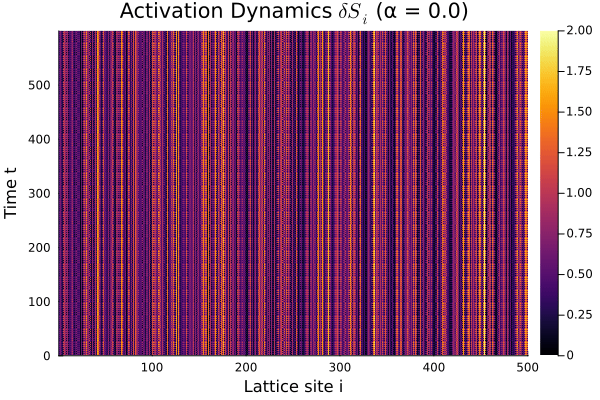

In [46]:
α_list = range(0.0, 1.0, length = 11)

anim = @animate for α in α_list
    times, dist_map = run_and_heatmap(α)

    heatmap(
        1:L,
        times,
        dist_map,
        xlabel = "Lattice site i",
        ylabel = "Time t",
        title = L"Activation Dynamics $\delta S_i$ (α = %$α)",
        aspect_ratio = :auto,
        clims = (0, 2.0)   # fixed color scale for comparison
    )
end

gif(anim, "activation_dynamics_alpha_sweep.gif", fps = 1)
